### Final evaluation of the models with the best hyperparameters across 10 seeds 
### Calibration analysis 
### Cloze analysis 
### Plots for the final report 

### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, GroupKFold, RandomizedSearchCV


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    log_loss
)

from xgboost import XGBClassifier
from scipy.stats import uniform, randint, loguniform

random_state = 42

### Load datasets

In [2]:
both_df = pd.read_csv("both_intervals_features.csv")
p600_df = pd.read_csv("p600_features.csv")
n400_df = pd.read_csv("n400_features.csv")

### Splitting function followed by other helper functions for evaluation

In [ ]:
def split(df, random_state):
    df = df.copy() # copy to not break anything

    df["label"] = (df["Cloze"] > 0).astype(int) # cloze = 0 -> class 0 else class = 1

    cloze = df["Cloze"]  # keep it for the cloze performance analysis

    X = df.drop(columns=["Cloze", "label", "trial_global", "Trial", "site", "subject_global"]) # only keep features for training
    y = df["label"] # target variable 
    groups = df["subject_global"] # for subject-based splitting and grid search

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state) # 80-20 split with subjects as group to avoid data leakage
    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    groups_train = groups.iloc[train_idx]
    groups_test = groups.iloc[test_idx]

    cloze_test = cloze.iloc[test_idx]  # also split original cloze to keep track of shuffling and splitting of each seed

    return X_train, X_test, y_train, y_test, groups_train, groups_test, cloze_test

In [ ]:
def evaluate_lr(X_train, X_test, y_train, y_test, best_params, random_state):
    final_lr = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty=best_params["model__penalty"],
            solver=best_params["model__solver"],
            C=best_params["model__C"],
            max_iter=best_params["model__max_iter"],
            random_state=random_state
        ))
    ]) # extract the best hyperparameters

    final_lr.fit(X_train, y_train) # fit the model on the training data

    y_pred = final_lr.predict(X_test) # make predictions
    y_prob = final_lr.predict_proba(X_test)[:, 1] # probabilities assigned to the predictions
    test_score_lr = balanced_accuracy_score(y_test, y_pred) # calculate balanced accuracy

    # save all of the evaluation metrics results
    results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "test_score_lr": test_score_lr,
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    return final_lr, results # return the final model

### Final evaluation for LR on the combined feature dataset across 10 seeds

In [ ]:
import json
import joblib

results_list = []

# use the best hyperparameters found in the FINAL_LR notebook
with open("lr_best_params.json") as f:
    best_params_final = json.load(f)

# evaluate across 10 seeds and derive standard deviation
for seed in range(10):
    print(f"\nRunning seed {seed}...")

    # split the data for the combined dataset
    X_train_both, X_test_both, y_train_both, y_test_both,  groups_train_both, groups_test_both, cloze_test_both = split(both_df, seed)

    # train model with the best hyperparameters
    final_lr_both, results_both = evaluate_lr(
        X_train_both,
        X_test_both,
        y_train_both,
        y_test_both,
        best_params_final,
        seed
    )

    # save results
    results_list.append({
        "seed": seed,
        "accuracy": results_both["accuracy"],
        "balanced_accuracy": results_both["balanced_accuracy"],
        "f1": results_both["f1"],
        "precision": results_both["precision"],
        "recall": results_both["recall"],
        "roc_auc": results_both["roc_auc"]
    })

    # save predictions for cloze analysis
    pred_df = pd.DataFrame({
        "y_true": y_test_both.values,
        "y_pred": results_both["y_pred"],
        "y_prob": results_both["y_prob"],
        "Cloze": cloze_test_both.values,
        "Seed": seed
    })

    pred_df.to_csv(f"lr_fixed_preds_seed_{seed}.csv", index=False)

    joblib.dump(final_lr_both, f"lr_fixed_model_seed_{seed}.joblib")

    pd.DataFrame(results_list).to_csv("lr_fixed_results_running.csv", index=False)

    print(f"Seed {seed} done.")

# save results across 10 seeds
results_df = pd.DataFrame(results_list)
results_df.to_csv("lr_fixed_results_final.csv", index=False)

metrics = ["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]

summary = {}

print("\nFinal Results (mean ± std):\n")

for metric in metrics:
    # calculate results as mean +/- std for all metrics
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std(ddof=1)
    
    # create summary
    summary[f"{metric}_mean"] = float(mean_val)
    summary[f"{metric}_std"] = float(std_val)

    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

# Save summary
with open("lr_fixed_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print("\nDone.")


Running seed 0...
Seed 0 done.

Running seed 1...
Seed 1 done.

Running seed 2...
Seed 2 done.

Running seed 3...
Seed 3 done.

Running seed 4...
Seed 4 done.

Running seed 5...
Seed 5 done.

Running seed 6...
Seed 6 done.

Running seed 7...
Seed 7 done.

Running seed 8...
Seed 8 done.

Running seed 9...
Seed 9 done.

Final Results (mean ± std):

accuracy: 0.5935 ± 0.0129
balanced_accuracy: 0.5931 ± 0.0127
f1: 0.5818 ± 0.0179
precision: 0.5880 ± 0.0196
recall: 0.5763 ± 0.0262
roc_auc: 0.6305 ± 0.0129

Done.


In [ ]:
def evaluate_xgb(X_train, X_test, y_train, y_test, best_params, random_state):
    final_xgb = Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBClassifier(
            max_depth=best_params["model__max_depth"],
            learning_rate=best_params["model__learning_rate"],
            n_estimators=best_params["model__n_estimators"],
            reg_lambda=best_params["model__reg_lambda"],
            subsample=best_params["model__subsample"],
            tree_method="hist",
            device="cuda",
            random_state=random_state,
            use_label_encoder=False,
            eval_metric="logloss"
        ))
    ])

    final_xgb.fit(X_train, y_train)

    y_pred = final_xgb.predict(X_test)
    y_prob = final_xgb.predict_proba(X_test)[:, 1]

    results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    return final_xgb, results

### Final evaluation for XGB on the combined feature dataset across 10 seeds

In [ ]:
results_list_xgb = [] # to save results across seeds

with open("xgb_both_best_params.json") as f:
    best_params_final_xgb = json.load(f) # extract the best hyperparameters found during training in FINAL_XGB

# repeat across 10 seeds
for seed in range(10):
    print(f"\nRunning seed {seed}...")

    # split data for final evaluation
    X_train_both_xgb, X_test_both_xgb, y_train_both_xgb, y_test_both_xgb, groups_train_both_xgb, groups_test_both_xgb, cloze_test_both_xgb = split(both_df, seed)

    # train model with the best hyperparameters
    final_xgb_both, results_both_xgb = evaluate_xgb(
        X_train_both_xgb,
        X_test_both_xgb,
        y_train_both_xgb,
        y_test_both_xgb,
        best_params_final_xgb,
        seed
    )

    # save results
    results_list_xgb.append({
        "seed": seed,
        "accuracy": results_both_xgb["accuracy"],
        "balanced_accuracy": results_both_xgb["balanced_accuracy"],
        "f1": results_both_xgb["f1"],
        "precision": results_both_xgb["precision"],
        "recall": results_both_xgb["recall"],
        "roc_auc": results_both_xgb["roc_auc"]
    })

    # save predictions for each seed
    pred_df_xgb = pd.DataFrame({
        "y_true": y_test_both_xgb.values,
        "y_pred": results_both_xgb["y_pred"],
        "y_prob": results_both_xgb["y_prob"],
        "Cloze": cloze_test_both_xgb.values,
        "Seed": seed
    })
    pred_df_xgb.to_csv(f"xgb_fixed_preds_seed_{seed}.csv", index=False)

    # save model
    joblib.dump(final_xgb_both, f"xgb_fixed_model_seed_{seed}.joblib")
    pd.DataFrame(results_list_xgb).to_csv("xgb_fixed_results_running.csv", index=False)

    print(f"Seed {seed} done.")

# save results across seeds
results_df_xgb = pd.DataFrame(results_list_xgb)
results_df_xgb.to_csv("xgb_fixed_results_final.csv", index=False)

metrics = ["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]

summary_xgb = {}

print("\nFinal XGB Results (mean ± std):\n")

# create summary
for metric in metrics:
    mean_val = results_df_xgb[metric].mean() # mean and std for each metric across 10 seeds
    std_val = results_df_xgb[metric].std(ddof=1)

    summary_xgb[f"{metric}_mean"] = float(mean_val)
    summary_xgb[f"{metric}_std"] = float(std_val)

    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

# Save summary
with open("xgb_fixed_summary.json", "w") as f:
    json.dump(summary_xgb, f, indent=4)

print("\nDone.")


Running seed 0...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:729: UserWarning: [15:20:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Seed 0 done.

Running seed 1...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 1 done.

Running seed 2...


...

Seed 7 done.

Running seed 8...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 8 done.

Running seed 9...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 9 done.

Final XGB Results (mean ± std):

accuracy: 0.5895 ± 0.0086
balanced_accuracy: 0.5889 ± 0.0086
f1: 0.5803 ± 0.0189
precision: 0.5823 ± 0.0170
recall: 0.5788 ± 0.0260
roc_auc: 0.6246 ± 0.0109

Done.


### Final evaluation for LR on the P600 feature dataset across 10 seeds - comments are only in the combined dataset. Sane procedure, just different variables and files

In [ ]:
results_list_p600 = []

with open("lr_best_params.json") as f:
    best_params_lr_global = json.load(f)

for seed in range(10):
    print(f"\nRunning seed {seed} (P600)...")

    X_train_p600, X_test_p600, y_train_p600, y_test_p600, \
    groups_train_p600, groups_test_p600, cloze_test_p600 = split(p600_df, seed)

    final_lr_p600, results_p600 = evaluate_lr(
        X_train_p600,
        X_test_p600,
        y_train_p600,
        y_test_p600,
        best_params_lr_global,
        seed
    )

    results_list_p600.append({
        "seed": seed,
        "accuracy": results_p600["accuracy"],
        "balanced_accuracy": results_p600["balanced_accuracy"],
        "f1": results_p600["f1"],
        "precision": results_p600["precision"],
        "recall": results_p600["recall"],
        "roc_auc": results_p600["roc_auc"]
    })

    pred_df_p600 = pd.DataFrame({
        "y_true": y_test_p600.values,
        "y_pred": results_p600["y_pred"],
        "y_prob": results_p600["y_prob"],
        "Cloze": cloze_test_p600.values,
        "Seed": seed
    })
    pred_df_p600.to_csv(f"lr_p600_preds_seed_{seed}.csv", index=False)

    joblib.dump(final_lr_p600, f"lr_p600_model_seed_{seed}.joblib")

    pd.DataFrame(results_list_p600).to_csv("lr_p600_results_running.csv", index=False)

    print(f"Seed {seed} done.")

results_df_p600 = pd.DataFrame(results_list_p600)
results_df_p600.to_csv("lr_p600_results_final.csv", index=False)

metrics = ["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]

summary_p600 = {}

print("\nFinal P600 Results (mean ± std):\n")

for metric in metrics:
    mean_val = results_df_p600[metric].mean()
    std_val = results_df_p600[metric].std(ddof=1)

    summary_p600[f"{metric}_mean"] = float(mean_val)
    summary_p600[f"{metric}_std"] = float(std_val)

    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

with open("lr_p600_summary.json", "w") as f:
    json.dump(summary_p600, f, indent=4)

print("\nDone.")


Running seed 0 (P600)...
Seed 0 done.

Running seed 1 (P600)...
Seed 1 done.

Running seed 2 (P600)...
Seed 2 done.

Running seed 3 (P600)...
Seed 3 done.

Running seed 4 (P600)...
Seed 4 done.

Running seed 5 (P600)...
Seed 5 done.

Running seed 6 (P600)...
Seed 6 done.

Running seed 7 (P600)...
Seed 7 done.

Running seed 8 (P600)...
Seed 8 done.

Running seed 9 (P600)...
Seed 9 done.

Final P600 Results (mean ± std):

accuracy: 0.5657 ± 0.0136
balanced_accuracy: 0.5653 ± 0.0132
f1: 0.5555 ± 0.0168
precision: 0.5586 ± 0.0167
recall: 0.5535 ± 0.0308
roc_auc: 0.5967 ± 0.0135

Done.


### Final evaluation for XGB on the P600 feature dataset across 10 seeds - comments are only in the combined dataset. Sane procedure, just different variables and files

In [ ]:
results_list_p600_xgb = []

with open("xgb_p6_best_params.json") as f:
    best_params_xgb_p6 = json.load(f)

for seed in range(10):
    print(f"\nRunning seed {seed} (P600)...")

    X_train_p600, X_test_p600, y_train_p600, y_test_p600, \
    groups_train_p600, groups_test_p600, cloze_test_p600 = split(p600_df, seed)

    final_xgb_p600, results_p600_xgb = evaluate_xgb(
        X_train_p600,
        X_test_p600,
        y_train_p600,
        y_test_p600,
        best_params_xgb_p6,
        seed
    )

    results_list_p600_xgb.append({
        "seed": seed,
        "accuracy": results_p600_xgb["accuracy"],
        "balanced_accuracy": results_p600_xgb["balanced_accuracy"],
        "f1": results_p600_xgb["f1"],
        "precision": results_p600_xgb["precision"],
        "recall": results_p600_xgb["recall"],
        "roc_auc": results_p600_xgb["roc_auc"]
    })

    pred_df_p600_xgb = pd.DataFrame({
        "y_true": y_test_p600.values,
        "y_pred": results_p600_xgb["y_pred"],
        "y_prob": results_p600_xgb["y_prob"],
        "Cloze": cloze_test_p600.values,
        "Seed": seed
    })
    pred_df_p600_xgb.to_csv(f"xgb_p600_preds_seed_{seed}.csv", index=False)

    joblib.dump(final_xgb_p600, f"xgb_p600_model_seed_{seed}.joblib")

    pd.DataFrame(results_list_p600_xgb).to_csv("xgb_p600_results_running.csv", index=False)

    print(f"Seed {seed} done.")

results_df_p600_xgb = pd.DataFrame(results_list_p600_xgb)
results_df_p600_xgb.to_csv("xgb_p600_results_final.csv", index=False)

metrics = ["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]

summary_p600_xgb = {}

print("\nFinal XGB P600 Results (mean ± std):\n")

for metric in metrics:
    mean_val = results_df_p600_xgb[metric].mean()
    std_val = results_df_p600_xgb[metric].std(ddof=1)

    summary_p600_xgb[f"{metric}_mean"] = float(mean_val)
    summary_p600_xgb[f"{metric}_std"] = float(std_val)

    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

with open("xgb_p600_summary.json", "w") as f:
    json.dump(summary_p600_xgb, f, indent=4)

print("\nDone.")


Running seed 0 (P600)...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 0 done.

Running seed 1 (P600)...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 1 done.

Running seed 2 (P600)...


...

Seed 7 done.

Running seed 8 (P600)...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 8 done.

Running seed 9 (P600)...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 9 done.

Final XGB P600 Results (mean ± std):

accuracy: 0.5695 ± 0.0135
balanced_accuracy: 0.5689 ± 0.0134
f1: 0.5572 ± 0.0220
precision: 0.5627 ± 0.0194
recall: 0.5526 ± 0.0338
roc_auc: 0.5971 ± 0.0102

Done.


### Final evaluation for LR on the N400 feature dataset across 10 seeds - comments are only in the combined dataset. Sane procedure, just different variables and files

In [ ]:
import json
import joblib
import pandas as pd

results_list_n400 = []

with open("lr_best_params.json") as f:
    best_params_lr_global = json.load(f)

for seed in range(10):
    print(f"\nRunning seed {seed} (N400)...")

    X_train_n400, X_test_n400, y_train_n400, y_test_n400, \
    groups_train_n400, groups_test_n400, cloze_test_n400 = split(n400_df, seed)

    final_lr_n400, results_n400 = evaluate_lr(
        X_train_n400,
        X_test_n400,
        y_train_n400,
        y_test_n400,
        best_params_lr_global,
        seed
    )

    results_list_n400.append({
        "seed": seed,
        "accuracy": results_n400["accuracy"],
        "balanced_accuracy": results_n400["balanced_accuracy"],
        "f1": results_n400["f1"],
        "precision": results_n400["precision"],
        "recall": results_n400["recall"],
        "roc_auc": results_n400["roc_auc"]
    })

    pred_df_n400 = pd.DataFrame({
        "y_true": y_test_n400.values,
        "y_pred": results_n400["y_pred"],
        "y_prob": results_n400["y_prob"],
        "Cloze": cloze_test_n400.values,
        "Seed": seed
    })
    pred_df_n400.to_csv(f"lr_n400_preds_seed_{seed}.csv", index=False)

    joblib.dump(final_lr_n400, f"lr_n400_model_seed_{seed}.joblib")

    pd.DataFrame(results_list_n400).to_csv("lr_n400_results_running.csv", index=False)

    print(f"Seed {seed} done.")

results_df_n400 = pd.DataFrame(results_list_n400)
results_df_n400.to_csv("lr_n400_results_final.csv", index=False)

metrics = ["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]

summary_n400 = {}

print("\nFinal N400 Results (mean ± std):\n")

for metric in metrics:
    mean_val = results_df_n400[metric].mean()
    std_val = results_df_n400[metric].std(ddof=1)

    summary_n400[f"{metric}_mean"] = float(mean_val)
    summary_n400[f"{metric}_std"] = float(std_val)

    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

with open("lr_n400_summary.json", "w") as f:
    json.dump(summary_n400, f, indent=4)

print("\nDone.")


Running seed 0 (N400)...
Seed 0 done.

Running seed 1 (N400)...
Seed 1 done.

Running seed 2 (N400)...
Seed 2 done.

Running seed 3 (N400)...
Seed 3 done.

Running seed 4 (N400)...
Seed 4 done.

Running seed 5 (N400)...
Seed 5 done.

Running seed 6 (N400)...
Seed 6 done.

Running seed 7 (N400)...
Seed 7 done.

Running seed 8 (N400)...
Seed 8 done.

Running seed 9 (N400)...
Seed 9 done.

Final N400 Results (mean ± std):

accuracy: 0.5519 ± 0.0118
balanced_accuracy: 0.5512 ± 0.0116
f1: 0.5291 ± 0.0194
precision: 0.5468 ± 0.0170
recall: 0.5135 ± 0.0320
roc_auc: 0.5771 ± 0.0145

Done.


### Final evaluation for XGB on the N400 feature dataset across 10 seeds - comments are only in the combined dataset. Sane procedure, just different variables and files

In [ ]:
results_list_n400_xgb = []

with open("xgb_n4_best_params.json") as f:
    best_params_xgb_n4 = json.load(f)

for seed in range(10):
    print(f"\nRunning seed {seed} (N400)...")

    X_train_n400, X_test_n400, y_train_n400, y_test_n400, \
    groups_train_n400, groups_test_n400, cloze_test_n400 = split(n400_df, seed)

    final_xgb_n400, results_n400_xgb = evaluate_xgb(
        X_train_n400,
        X_test_n400,
        y_train_n400,
        y_test_n400,
        best_params_xgb_n4,
        seed
    )

    results_list_n400_xgb.append({
        "seed": seed,
        "accuracy": results_n400_xgb["accuracy"],
        "balanced_accuracy": results_n400_xgb["balanced_accuracy"],
        "f1": results_n400_xgb["f1"],
        "precision": results_n400_xgb["precision"],
        "recall": results_n400_xgb["recall"],
        "roc_auc": results_n400_xgb["roc_auc"]
    })

    pred_df_n400_xgb = pd.DataFrame({
        "y_true": y_test_n400.values,
        "y_pred": results_n400_xgb["y_pred"],
        "y_prob": results_n400_xgb["y_prob"],
        "Cloze": cloze_test_n400.values,
        "Seed": seed
    })
    pred_df_n400_xgb.to_csv(f"xgb_n400_preds_seed_{seed}.csv", index=False)

    joblib.dump(final_xgb_n400, f"xgb_n400_model_seed_{seed}.joblib")

    pd.DataFrame(results_list_n400_xgb).to_csv("xgb_n400_results_running.csv", index=False)

    print(f"Seed {seed} done.")

results_df_n400_xgb = pd.DataFrame(results_list_n400_xgb)
results_df_n400_xgb.to_csv("xgb_n400_results_final.csv", index=False)

metrics = ["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]

summary_n400_xgb = {}

print("\nFinal XGB N400 Results (mean ± std):\n")

for metric in metrics:
    mean_val = results_df_n400_xgb[metric].mean()
    std_val = results_df_n400_xgb[metric].std(ddof=1)

    summary_n400_xgb[f"{metric}_mean"] = float(mean_val)
    summary_n400_xgb[f"{metric}_std"] = float(std_val)

    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

with open("xgb_n400_summary.json", "w") as f:
    json.dump(summary_n400_xgb, f, indent=4)

print("\nDone.")


Running seed 0 (N400)...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 0 done.

Running seed 1 (N400)...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 1 done.

Running seed 2 (N400)...


...

Seed 7 done.

Running seed 8 (N400)...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 8 done.

Running seed 9 (N400)...


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:20:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Seed 9 done.

Final XGB N400 Results (mean ± std):

accuracy: 0.5631 ± 0.0115
balanced_accuracy: 0.5620 ± 0.0115
f1: 0.5308 ± 0.0186
precision: 0.5617 ± 0.0215
recall: 0.5040 ± 0.0265
roc_auc: 0.5861 ± 0.0149

Done.


### Balanced Accuracy and Brier Score as a function of cloze

In [3]:
from sklearn.metrics import balanced_accuracy_score, brier_score_loss
import glob

files = glob.glob("lr_fixed_preds_seed_*.csv") # retrieve predictions for LR mdel on the combined dataset for all seeds

# read the predictions
all_dfs = []
for f in files:
    df = pd.read_csv(f)
    all_dfs.append(df)

# concatenate them
all_preds_df = pd.concat(all_dfs, ignore_index=True)

# create bins of 0.1 increments of cloze probability; e.g., cloze = 0.76 -> bin = 0.7
all_preds_df["Cloze_bin"] = np.floor(all_preds_df["Cloze"] * 10) / 10
all_preds_df["Cloze_bin"] = all_preds_df["Cloze_bin"].round(1)

results = [] 

# for each seed and cloze bin
for (seed, bin_val), df_group in all_preds_df.groupby(["Seed", "Cloze_bin"]):

    # retrievve predictions, true labels and associated probabilities with the predictions
    y_true = df_group["y_true"]
    y_pred = df_group["y_pred"]
    y_prob = df_group["y_prob"]

    # skip very tiny bins
    if len(df_group) < 20:
        continue

    # compute balanced accuracy for the current cloze bin + brier score
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    brier = brier_score_loss(y_true, y_prob)

    # save results for the current seed
    results.append({
        "seed": seed,
        "Cloze_bin": bin_val,
        "balanced_accuracy": bal_acc,
        "brier_score": brier,
        "n_samples": len(df_group)
    })

results_df = pd.DataFrame(results)

# create summary as mean +/- std for balanced accuracy and brier
summary_df = results_df.groupby("Cloze_bin").agg({
    "balanced_accuracy": ["mean", "std"],
    "brier_score": ["mean", "std"],
    "n_samples": "mean"
})

summary_df = summary_df.round(3)
print("\nCloze-bin performance (LR bothh:\n")
print(summary_df)


Cloze-bin performance (LR bothh:

          balanced_accuracy        brier_score        n_samples
                       mean    std        mean    std      mean
Cloze_bin                                                      
0.0                   0.541  0.024       0.236  0.006    1067.2
0.1                   0.533  0.064       0.257  0.017      80.5
0.2                   0.512  0.060       0.263  0.017      91.2
0.3                   0.526  0.054       0.255  0.013      55.2
0.4                   0.547  0.063       0.254  0.017      77.1
0.5                   0.586  0.030       0.236  0.009     141.1
0.6                   0.563  0.062       0.246  0.013      79.9
0.7                   0.645  0.051       0.221  0.011      72.5
0.8                   0.586  0.052       0.242  0.017      70.6
0.9                   0.683  0.046       0.209  0.013      77.5
1.0                   0.695  0.046       0.206  0.009      86.0


c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:2801

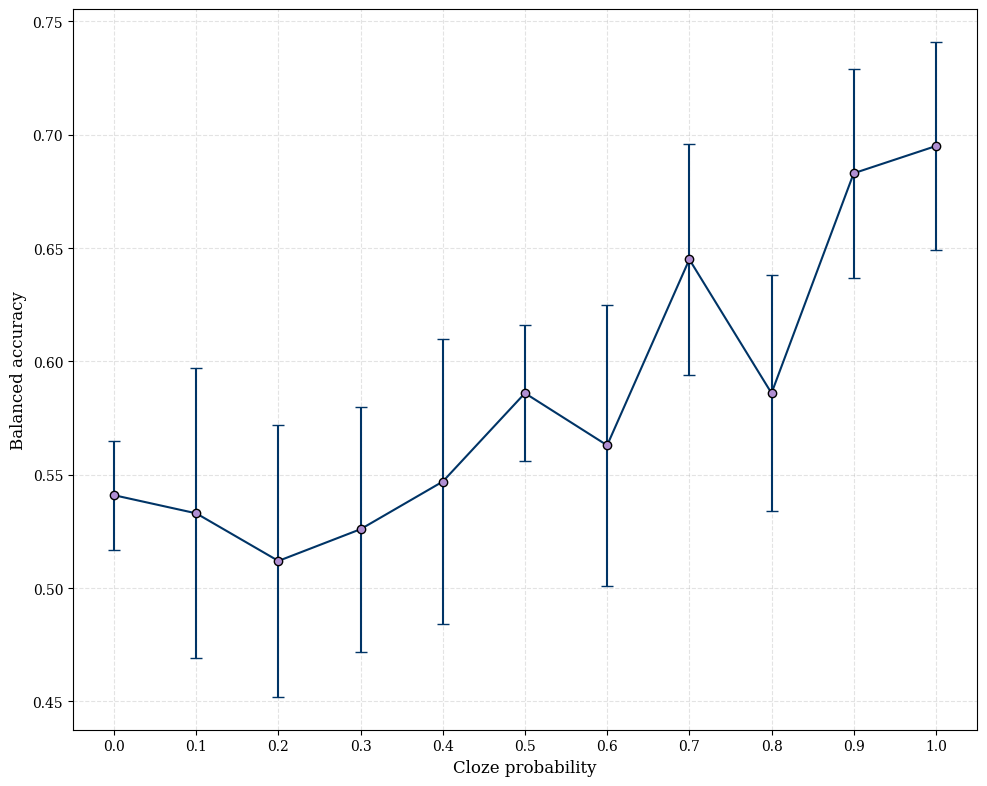

In [4]:
# style used for all plots
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

summary_df = summary_df.sort_index()
# retrieve balanced accuracy mean and std per cloze bin
x = summary_df.index.values
acc_mean = summary_df[("balanced_accuracy", "mean")]
acc_std = summary_df[("balanced_accuracy", "std")]

# create plot
plt.figure(figsize=(10, 8))

plt.errorbar(
    x,
    acc_mean,
    yerr=acc_std,
    fmt='o-',                     
    color="#003466",               
    ecolor="#003466",
    elinewidth=1.5,
    capsize=4,
    markerfacecolor="#B08FD3",  
    markeredgecolor="black",
    markersize=6
)

# Axis labels
plt.xlabel("Cloze probability")
plt.ylabel("Balanced accuracy")

plt.xticks(x)

# grid within the plot
plt.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("cloze_performance.pdf", bbox_inches="tight")
plt.show()

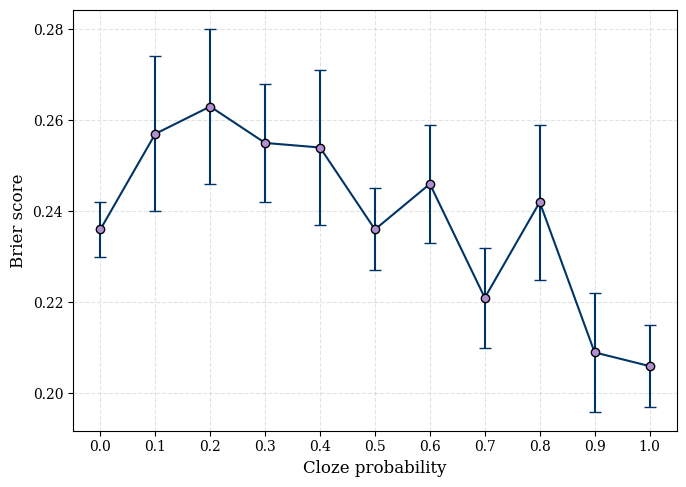

In [ ]:
# same style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})


summary_df = summary_df.sort_index()
# retrieve Brier score mean and std per cloze bin
x = summary_df.index.astype(float)
brier_mean = summary_df[("brier_score", "mean")]
brier_std = summary_df[("brier_score", "std")]

# plot
plt.figure(figsize=(7, 5))
# plot errorbars with the std
plt.errorbar(
    x,
    brier_mean,
    yerr=brier_std,
    fmt='o-',            
    color="#003466",              
    ecolor="#003466",
    elinewidth=1.5,
    capsize=4,
    markerfacecolor="#B08FD3",   
    markeredgecolor="black",
    markersize=6
)

# axis labels
plt.xlabel("Cloze probability")
plt.ylabel("Brier score")

plt.xticks(x)

# grid within the plot
plt.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("brier_cloze.pdf", bbox_inches="tight")
plt.show()

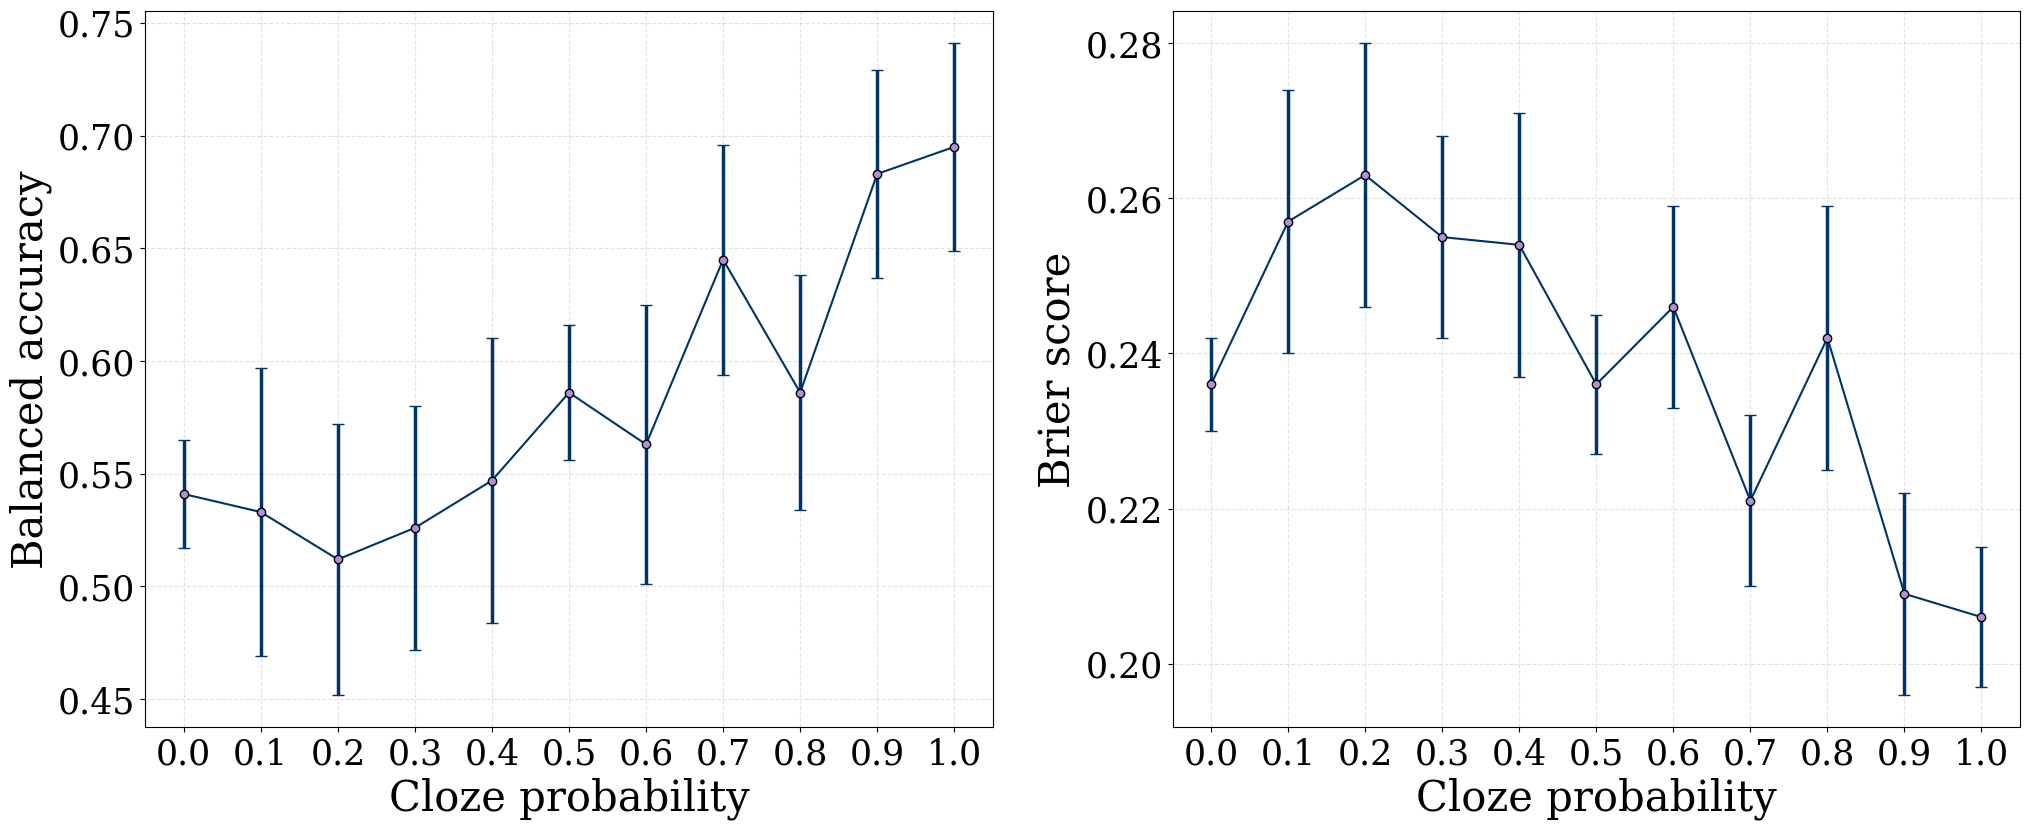

In [16]:
# same style as thesis
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 30,
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25
})

summary_df = summary_df.sort_index()

# retrieve balanced accuracy and brier score mean and std per cloze bin
x = summary_df.index.astype(float)
acc_mean = summary_df[("balanced_accuracy", "mean")]
acc_std = summary_df[("balanced_accuracy", "std")]
brier_mean = summary_df[("brier_score", "mean")]
brier_std = summary_df[("brier_score", "std")]

# figure with both plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 9))
plt.subplots_adjust(wspace=0.4)

# left -> balanced accuracy vs cloze

# plot errorbars with the std
ax1.errorbar(
    x, acc_mean, yerr=acc_std,
    fmt='o-',
    color="#003466",
    ecolor="#003466",
    elinewidth=2.5,
    capsize=4,
    markerfacecolor="#B08FD3",
    markeredgecolor="black",
    markersize=6
)
# Axis labels
ax1.set_xlabel("Cloze probability")
ax1.set_ylabel("Balanced accuracy")
ax1.set_xticks(x)
# grid within the plot
ax1.grid(True, linestyle="--", alpha=0.35)

# right = brier vs cloze
# plot errorbars with the std
ax2.errorbar(
    x, brier_mean, yerr=brier_std,
    fmt='o-',
    color="#003466",
    ecolor="#003466",
    elinewidth=2.5,
    capsize=4,
    markerfacecolor="#B08FD3",
    markeredgecolor="black",
    markersize=6
)
# axis labels
ax2.set_xlabel("Cloze probability")
ax2.set_ylabel("Brier score")
ax2.set_xticks(x)
# grid within the plot
ax2.grid(True, linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("cloze_performance_combined.pdf", bbox_inches="tight")
plt.show()

### Callibration plot
### Code retrieved from: https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html

In [22]:
from matplotlib.gridspec import GridSpec
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.linear_model import LogisticRegression

# analysis on the combined dataset (best performance)
# train model with the best hyperparameters -> LR because it was the best and has the best calibration
X_train_both, X_test_both, y_train_both, y_test_both,  groups_train_both, groups_test_both, cloze_test_both = split(both_df, seed)
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=0.001,
        max_iter=5000,
        random_state=random_state
    ))
])

lr.fit(X_train_both, y_train_both)

clf_list = [
    (lr, "Logistic Regression")
]

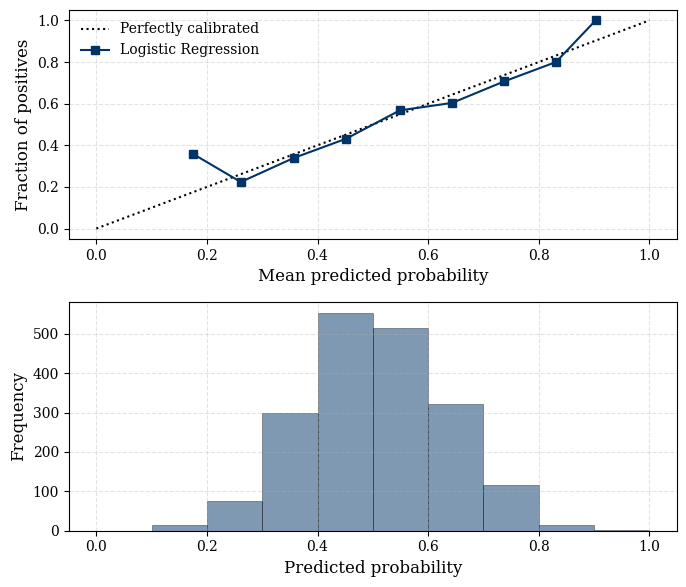

In [23]:
from sklearn.calibration import CalibrationDisplay

# same plot style 
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

colors = ["#003466", "#B08FD3", "#6FA3EF"] 

fig = plt.figure(figsize=(7, 6))
ax_cal = fig.add_subplot(2, 1, 1) # two plots on top of eachother

# PLOT CODE FROM SK-LEARN DOCUMENTATION

calibration_displays = {}

for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train_both, y_train_both)
    display = CalibrationDisplay.from_estimator(
        clf,
        X_test_both,
        y_test_both,
        n_bins=10,
        name=name,
        ax=ax_cal,
        color=colors[i],
    )

    calibration_displays[name] = display

ax_cal.grid(True, linestyle="--", alpha=0.35)
ax_cal.set_xlabel("Mean predicted probability")
ax_cal.set_ylabel("Fraction of positives")


ax_hist = fig.add_subplot(2, 1, 2)

for i, (_, name) in enumerate(clf_list):
    ax_hist.hist(
        calibration_displays[name].y_prob,
        bins=10,
        range=(0, 1),
        alpha=0.5,
        color=colors[i],
        label=name,
        edgecolor="black",
        linewidth=0.5
    )

ax_hist.set_xlabel("Predicted probability")
ax_hist.set_ylabel("Frequency")
ax_hist.grid(True, linestyle="--", alpha=0.35)

ax_cal.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig("calibration.pdf", bbox_inches="tight")
plt.show()

### Final evaluation of Naive Bayes across 10 seeds

In [24]:
from sklearn.naive_bayes import GaussianNB
def evaluate_nb(X_train, X_test, y_train, y_test, best_params, random_state):
    # no hyperparameters, just use default and scaling for consistency with LR
    final_nb = Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB(
            var_smoothing=best_params["model__var_smoothing"]
        ))
    ])
    
    final_nb.fit(X_train, y_train)

    y_pred = final_nb.predict(X_test)
    y_prob = final_nb.predict_proba(X_test)[:, 1]
    test_score_nb = balanced_accuracy_score(y_test, y_pred)

    results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": test_score_nb,
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "test_score_nb": test_score_nb,
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    return final_nb, results

### Final evaluation for NB on the N400 feature dataset across 10 seeds 

In [25]:
results_list_n400_nb = []

# default for pipeline consistency
best_params_nb = {
    "model__var_smoothing": 1e-9
}

# evaluate across 10 seeds
for seed in range(10):
    print(f"\nRunning seed {seed} (N400 NB)...")

    # split data
    X_train_n400, X_test_n400, y_train_n400, y_test_n400, \
    groups_train_n400, groups_test_n400, cloze_test_n400 = split(n400_df, seed)

    # train and evaluate
    final_nb_n400, results_n400_nb = evaluate_nb(
        X_train_n400,
        X_test_n400,
        y_train_n400,
        y_test_n400,
        best_params_nb,
        seed
    )

    # save results for the current seed
    results_list_n400_nb.append({
        "seed": seed,
        "accuracy": results_n400_nb["accuracy"],
        "balanced_accuracy": results_n400_nb["balanced_accuracy"],
        "f1": results_n400_nb["f1"],
        "precision": results_n400_nb["precision"],
        "recall": results_n400_nb["recall"],
        "roc_auc": results_n400_nb["roc_auc"]
    })

    # save predictions for the current seed
    pred_df_n400_nb = pd.DataFrame({
        "y_true": y_test_n400.values,
        "y_pred": results_n400_nb["y_pred"],
        "y_prob": results_n400_nb["y_prob"],
        "Cloze": cloze_test_n400.values,
        "Seed": seed
    })
    pred_df_n400_nb.to_csv(f"nb_n400_preds_seed_{seed}.csv", index=False)

    # save model
    joblib.dump(final_nb_n400, f"nb_n400_model_seed_{seed}.joblib")
    pd.DataFrame(results_list_n400_nb).to_csv("nb_n400_results_running.csv", index=False)

    print(f"Seed {seed} done.")

# save results across seeds
results_df_n400_nb = pd.DataFrame(results_list_n400_nb)
results_df_n400_nb.to_csv("nb_n400_results_final.csv", index=False)

# metrics to be computed
metrics = ["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]

# create summaary of metrics
summary_n400_nb = {}

print("\nFinal NB N400 Results (mean ± std):\n")

for metric in metrics:
    mean_val = results_df_n400_nb[metric].mean()
    std_val = results_df_n400_nb[metric].std(ddof=1) # mean and std for all metrics across 10 seeds

    summary_n400_nb[f"{metric}_mean"] = float(mean_val)
    summary_n400_nb[f"{metric}_std"] = float(std_val)

    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

with open("nb_n400_summary.json", "w") as f:
    json.dump(summary_n400_nb, f, indent=4)

print("\nDone.")


Running seed 0 (N400 NB)...
Seed 0 done.

Running seed 1 (N400 NB)...
Seed 1 done.

Running seed 2 (N400 NB)...
Seed 2 done.

Running seed 3 (N400 NB)...
Seed 3 done.

Running seed 4 (N400 NB)...
Seed 4 done.

Running seed 5 (N400 NB)...
Seed 5 done.

Running seed 6 (N400 NB)...
Seed 6 done.

Running seed 7 (N400 NB)...
Seed 7 done.

Running seed 8 (N400 NB)...
Seed 8 done.

Running seed 9 (N400 NB)...
Seed 9 done.

Final NB N400 Results (mean ± std):

accuracy: 0.5483 ± 0.0116
balanced_accuracy: 0.5470 ± 0.0116
f1: 0.5088 ± 0.0205
precision: 0.5460 ± 0.0204
recall: 0.4770 ± 0.0280
roc_auc: 0.5669 ± 0.0117

Done.


### Final evaluation for NB on the P600 feature dataset across 10 seeds - comments are only in the N400 dataset. Sane procedure, just different variables and files

In [26]:
results_list_p600_nb = []

best_params_nb = {
    "model__var_smoothing": 1e-9
}

for seed in range(10):
    print(f"\nRunning seed {seed} (P600 NB)...")

    X_train_p600, X_test_p600, y_train_p600, y_test_p600, \
    groups_train_p600, groups_test_p600, cloze_test_p600 = split(p600_df, seed)

    final_nb_p600, results_p600_nb = evaluate_nb(
        X_train_p600,
        X_test_p600,
        y_train_p600,
        y_test_p600,
        best_params_nb,
        seed
    )

    results_list_p600_nb.append({
        "seed": seed,
        "accuracy": results_p600_nb["accuracy"],
        "balanced_accuracy": results_p600_nb["balanced_accuracy"],
        "f1": results_p600_nb["f1"],
        "precision": results_p600_nb["precision"],
        "recall": results_p600_nb["recall"],
        "roc_auc": results_p600_nb["roc_auc"]
    })

    pred_df_p600_nb = pd.DataFrame({
        "y_true": y_test_p600.values,
        "y_pred": results_p600_nb["y_pred"],
        "y_prob": results_p600_nb["y_prob"],
        "Cloze": cloze_test_p600.values,
        "Seed": seed
    })
    pred_df_p600_nb.to_csv(f"nb_p600_preds_seed_{seed}.csv", index=False)

    joblib.dump(final_nb_p600, f"nb_p600_model_seed_{seed}.joblib")

    pd.DataFrame(results_list_p600_nb).to_csv("nb_p600_results_running.csv", index=False)

    print(f"Seed {seed} done.")

results_df_p600_nb = pd.DataFrame(results_list_p600_nb)
results_df_p600_nb.to_csv("nb_p600_results_final.csv", index=False)

metrics = ["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]

summary_p600_nb = {}

print("\nFinal NB P600 Results (mean ± std):\n")

for metric in metrics:
    mean_val = results_df_p600_nb[metric].mean()
    std_val = results_df_p600_nb[metric].std(ddof=1)

    summary_p600_nb[f"{metric}_mean"] = float(mean_val)
    summary_p600_nb[f"{metric}_std"] = float(std_val)

    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

with open("nb_p600_summary.json", "w") as f:
    json.dump(summary_p600_nb, f, indent=4)

print("\nDone.")


Running seed 0 (P600 NB)...
Seed 0 done.

Running seed 1 (P600 NB)...
Seed 1 done.

Running seed 2 (P600 NB)...
Seed 2 done.

Running seed 3 (P600 NB)...
Seed 3 done.

Running seed 4 (P600 NB)...
Seed 4 done.

Running seed 5 (P600 NB)...
Seed 5 done.

Running seed 6 (P600 NB)...
Seed 6 done.

Running seed 7 (P600 NB)...
Seed 7 done.

Running seed 8 (P600 NB)...
Seed 8 done.

Running seed 9 (P600 NB)...
Seed 9 done.

Final NB P600 Results (mean ± std):

accuracy: 0.5442 ± 0.0113
balanced_accuracy: 0.5448 ± 0.0105
f1: 0.5620 ± 0.0253
precision: 0.5319 ± 0.0162
recall: 0.5975 ± 0.0468
roc_auc: 0.5608 ± 0.0133

Done.


### Final evaluation for NB on the combined feature dataset across 10 seeds - comments are only in the N400 dataset. Sane procedure, just different variables and files

In [27]:
results_list_both_nb = []

best_params_nb = {
    "model__var_smoothing": 1e-9
}

for seed in range(10):
    print(f"\nRunning seed {seed} (Combined NB)...")

    X_train_both, X_test_both, y_train_both, y_test_both, \
    groups_train_both, groups_test_both, cloze_test_both = split(both_df, seed)

    final_nb_both, results_both_nb = evaluate_nb(
        X_train_both,
        X_test_both,
        y_train_both,
        y_test_both,
        best_params_nb,
        seed
    )

    results_list_both_nb.append({
        "seed": seed,
        "accuracy": results_both_nb["accuracy"],
        "balanced_accuracy": results_both_nb["balanced_accuracy"],
        "f1": results_both_nb["f1"],
        "precision": results_both_nb["precision"],
        "recall": results_both_nb["recall"],
        "roc_auc": results_both_nb["roc_auc"]
    })

    pred_df_both_nb = pd.DataFrame({
        "y_true": y_test_both.values,
        "y_pred": results_both_nb["y_pred"],
        "y_prob": results_both_nb["y_prob"],
        "Cloze": cloze_test_both.values,
        "Seed": seed
    })
    pred_df_both_nb.to_csv(f"nb_both_preds_seed_{seed}.csv", index=False)

    joblib.dump(final_nb_both, f"nb_both_model_seed_{seed}.joblib")

    pd.DataFrame(results_list_both_nb).to_csv("nb_both_results_running.csv", index=False)

    print(f"Seed {seed} done.")

results_df_both_nb = pd.DataFrame(results_list_both_nb)
results_df_both_nb.to_csv("nb_both_results_final.csv", index=False)

metrics = ["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]

summary_both_nb = {}

print("\nFinal NB Combined Results (mean ± std):\n")

for metric in metrics:
    mean_val = results_df_both_nb[metric].mean()
    std_val = results_df_both_nb[metric].std(ddof=1)

    summary_both_nb[f"{metric}_mean"] = float(mean_val)
    summary_both_nb[f"{metric}_std"] = float(std_val)

    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

with open("nb_both_summary.json", "w") as f:
    json.dump(summary_both_nb, f, indent=4)

print("\nDone.")


Running seed 0 (Combined NB)...
Seed 0 done.

Running seed 1 (Combined NB)...
Seed 1 done.

Running seed 2 (Combined NB)...
Seed 2 done.

Running seed 3 (Combined NB)...
Seed 3 done.

Running seed 4 (Combined NB)...
Seed 4 done.

Running seed 5 (Combined NB)...
Seed 5 done.

Running seed 6 (Combined NB)...
Seed 6 done.

Running seed 7 (Combined NB)...
Seed 7 done.

Running seed 8 (Combined NB)...
Seed 8 done.

Running seed 9 (Combined NB)...
Seed 9 done.

Final NB Combined Results (mean ± std):

accuracy: 0.5718 ± 0.0114
balanced_accuracy: 0.5712 ± 0.0110
f1: 0.5604 ± 0.0333
precision: 0.5648 ± 0.0200
recall: 0.5593 ± 0.0581
roc_auc: 0.6027 ± 0.0126

Done.


### McNemar test

### For the combined dataset, load the predictions for all seeds and models and concatenate them

In [28]:
all_lr_b = pd.concat([pd.read_csv(f"lr_fixed_preds_seed_{i}.csv") for i in range(10)])
all_xgb_b = pd.concat([pd.read_csv(f"xgb_fixed_preds_seed_{i}.csv") for i in range(10)])
all_nb_b = pd.concat([pd.read_csv(f"nb_both_preds_seed_{i}.csv") for i in range(10)])

### LR vs NB -> significant

In [29]:
from statsmodels.stats.contingency_tables import mcnemar

lr_correct = all_lr_b["y_pred"] == all_lr_b["y_true"] # where lr predicts true label
nb_correct = all_nb_b["y_pred"] == all_nb_b["y_true"] # where nb predicts true label

b = ((lr_correct == 1) & (nb_correct == 0)).sum() # where lr is correct and nb isn't
c = ((lr_correct == 0) & (nb_correct == 1)).sum() # where nb is correct and lr isn't

table = [[0, b],
         [c, 0]]

result = mcnemar(table, exact=True)

print("b:", b, "c:", c)
print("p-value:", result.pvalue)

b: 2519 c: 2104
p-value: 1.1090780778615357e-09


### LR vs XGB -> no significant difference

In [30]:
lr_correct = all_lr_b["y_pred"] == all_lr_b["y_true"] # where lr predicts true label
xgb_correct = all_xgb_b["y_pred"] == all_xgb_b["y_true"] # where xgb predicts true label

b = ((lr_correct == 1) & (xgb_correct == 0)).sum() # where lr is correct and xgb isn't
c = ((lr_correct == 0) & (xgb_correct == 1)).sum() # where xgb is correct and lr isn't

table = [[0, b],
         [c, 0]]

result = mcnemar(table, exact=True)

print("b:", b, "c:", c)
print("p-value:", result.pvalue)

b: 2112 c: 2037
p-value: 0.2506184256538532


### NB vs XGB -> significant

In [31]:
xgb_correct = all_xgb_b["y_pred"] == all_xgb_b["y_true"] # where xgb predicts true label
nb_correct = all_nb_b["y_pred"] == all_nb_b["y_true"] # where nb predicts true label

b = ((xgb_correct == 1) & (nb_correct == 0)).sum() # where xgb is correct and nb isn't
c = ((xgb_correct == 0) & (nb_correct == 1)).sum() # where nb is correct and xgb isn't

table = [[0, b],
         [c, 0]]

result = mcnemar(table, exact=True)

print("b:", b, "c:", c)
print("p-value:", result.pvalue)

b: 2887 c: 2547
p-value: 4.221385605748859e-06


### Permutation test for Logistic Regression on the combined dataset

In [32]:
from sklearn.utils import shuffle

X_train_both, X_test_both, y_train_both, y_test_both,  groups_train_both, groups_test_both, cloze_test_both = split(both_df, 0) # split the data, use only one seed

n = 3000 # 3,000 repetitions
perm_balanced_accuracy = [] # keep track of the permuted scores

for i in range(n):

    # shuffle training labels
    y_perm = shuffle(y_train_both, random_state=i)

    # use the best hyperparameters
    perm_lr_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l2",
            solver="lbfgs", 
            C=0.001,
            max_iter=5000
        ))
    ])

    perm_lr_model.fit(X_train_both, y_perm) # fit model on permuted labels

    y_pred_perm = perm_lr_model.predict(X_test_both) # predict 

    # evaluate 
    perm_score = balanced_accuracy_score(y_test_both, y_pred_perm)
    perm_balanced_accuracy.append(perm_score) # save score

In [33]:
# retrieve true score with mean and std across seeds
with open("lr_fixed_summary.json", "r") as f:
    data = json.load(f)

bal_acc_mean = data["balanced_accuracy_mean"]
bal_acc_std = data["balanced_accuracy_std"]

perm_balanced_accuracy = np.array(perm_balanced_accuracy)
p_value = (np.sum(perm_balanced_accuracy >= bal_acc_mean) + 1) / (n + 1) # to avoid a p-value of exactly 0, add 1. Count all times when the permuted classifier outperformed the correct one
print("Permutation p-value:", p_value)

Permutation p-value: 0.0003332222592469177


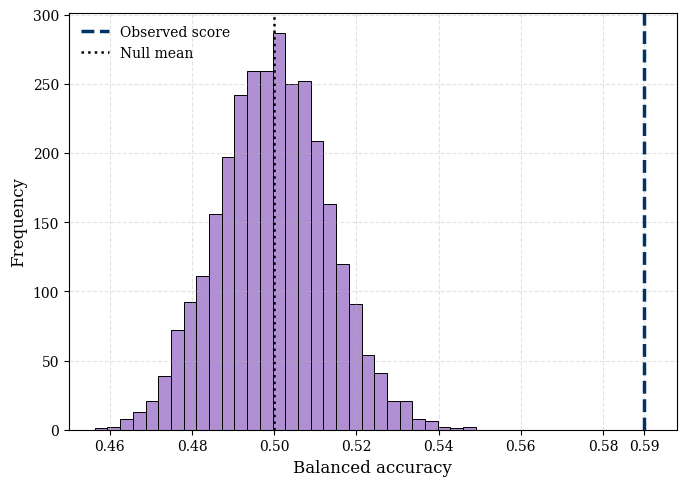

In [34]:
# keep same style as all figures
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

# compute the mean of the null distribution
null_mean = np.mean(perm_balanced_accuracy)
observed = round(bal_acc_mean, 2) # the actual observed balanced accuracy score

# plot
plt.figure(figsize=(7, 5))

# the distribution of permuted scores
plt.hist(
    perm_balanced_accuracy,
    bins=30,
    color="#B08FD3",
    edgecolor="black",
    linewidth=0.7
)

# dotted line corresponding to the true score
plt.axvline(
    observed,
    color="#003466",
    linewidth=2.5,
    linestyle="--",
    label="Observed score"
)

# line corresponding to the mean of the null distribution
plt.axvline(
    null_mean,
    color="black",
    linestyle=":",
    linewidth=1.8,
    label="Null mean"
)

plt.xlabel("Balanced accuracy")
plt.ylabel("Frequency")

# spacing
xmin = 0.45
xmax = observed + 0.008 

plt.xlim(xmin, xmax)

# Adjust ticks so it is not too crowded
base_ticks = [0.46, 0.48, 0.50, 0.52, 0.54, 0.56, 0.58]
xticks = sorted(base_ticks + [observed])

plt.xticks(xticks)

plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(frameon=False, loc="upper left")

# save
plt.tight_layout()
plt.savefig("perm.pdf", bbox_inches="tight")
plt.show()

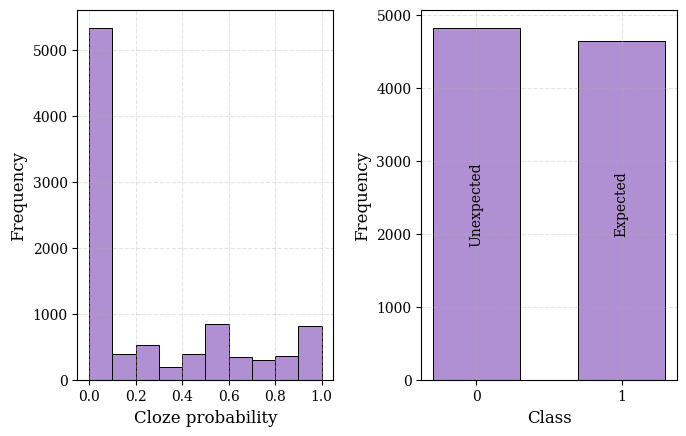

In [35]:
# keep same style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

# extract initial cloze values and cloze labels
both_cloze = both_df["Cloze"]
both_label = (both_df["Cloze"] > 0).astype(int) # cloze = 0 -> class 0 else class = 1

# figure with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(7, 4.5))

# Left = original distribution
ax[0].hist(
    both_cloze,
    bins=10,
    edgecolor="black",
    linewidth=0.7,
    color="#B08FD3"
)
ax[0].set_xlabel("Cloze probability")
ax[0].set_ylabel("Frequency")
ax[0].grid(True, linestyle="--", alpha=0.35)

# right = binarized distribution
counts, bins, patches = ax[1].hist(
    both_label,
    bins=[-0.5, 0.5, 1.5],
    rwidth=0.6,
    edgecolor="black",
    linewidth=0.7,
    color="#B08FD3"
)
ax[1].set_xlabel("Class")
ax[1].set_ylabel("Frequency")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["0", "1"])
ax[1].grid(True, linestyle="--", alpha=0.35)

# Add class names inside of the bars
labels = ["Unexpected", "Expected"]
y_pos = max(counts) * 0.5
for i, count in enumerate(counts):
    ax[1].text(
        i, y_pos, labels[i],
        ha="center", va="center",
        rotation=90, fontsize=10, color="black"
    )

# save
plt.tight_layout()
plt.savefig("cloze_distr.pdf", bbox_inches="tight")
plt.show()

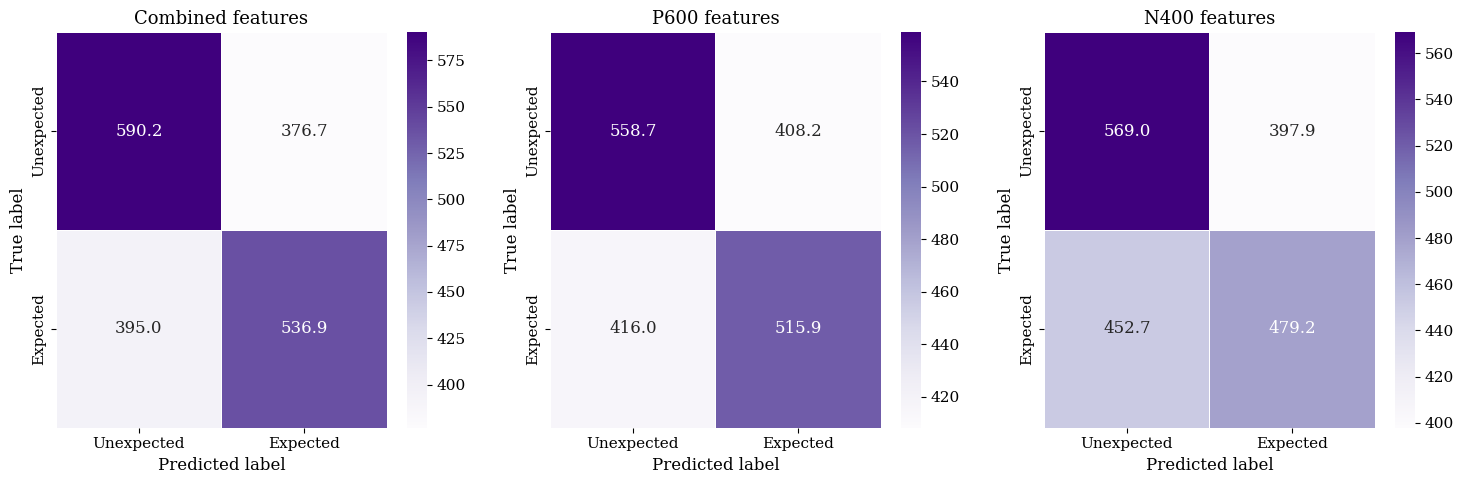

In [45]:
# keep same style as all figures
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

datasets = [(both_df, "Combined features"), (p600_df, "P600 features"), (n400_df, "N400 features")]

# three subplots, one for each dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.subplots_adjust(wspace=0.6)

for ax, (df, title) in zip(axes, datasets):

    # store confusion matrices across seeds
    all_confusion_lr = []

    for seed in range(10):
        X_train, X_test, y_train, y_test, _, _, _ = split(df, seed)
        _, results = evaluate_lr(X_train, X_test, y_train, y_test, best_params_final, seed)
        all_confusion_lr.append(results["confusion_matrix"])

    # average confusion matrix across seeds
    mean_confusion = np.mean(all_confusion_lr, axis=0)

    sns.heatmap(
        mean_confusion,
        annot=True,
        fmt=".1f",          # one decimal since these are averaged counts
        cmap="Purples",
        xticklabels=["Unexpected", "Expected"],
        yticklabels=["Unexpected", "Expected"],
        linewidths=0.5,
        ax=ax,
        annot_kws={"size": 12}
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

# save
plt.tight_layout()
plt.savefig("confusion_matrix_lr_all.pdf", bbox_inches="tight")
plt.show()

c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:43:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:43:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:43:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\maria\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [15:43:56] WARNING: C:\actio

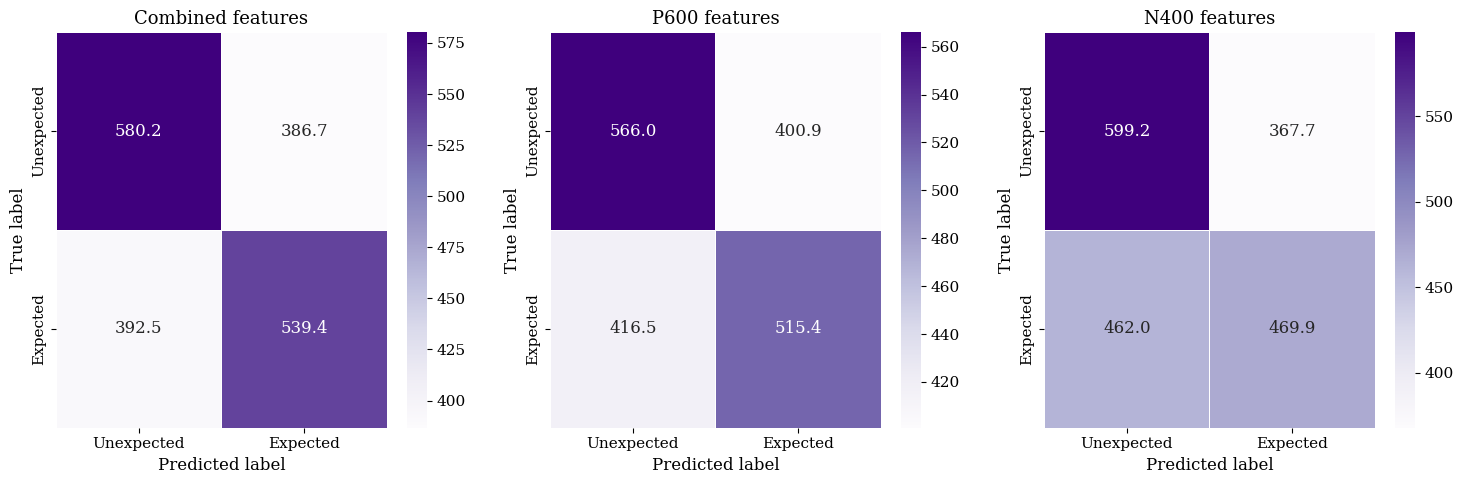

In [50]:
# keep same style as all figures
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

# load best hyperparameters per dataset found during nested CV
with open("xgb_both_best_params.json") as f:
    best_params_xgb_both = json.load(f)
with open("xgb_p6_best_params.json") as f:
    best_params_xgb_p600 = json.load(f)
with open("xgb_n4_best_params.json") as f:
    best_params_xgb_n400 = json.load(f)

datasets = [
    (both_df, "Combined features", best_params_xgb_both),
    (p600_df, "P600 features", best_params_xgb_p600),
    (n400_df, "N400 features", best_params_xgb_n400)
]

# three subplots, one for each dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.subplots_adjust(wspace=0.6)

for ax, (df, title, best_params) in zip(axes, datasets):

    # store confusion matrices across seeds
    all_confusion_xgb = []

    for seed in range(10):
        X_train, X_test, y_train, y_test, _, _, _ = split(df, seed)
        _, results = evaluate_xgb(X_train, X_test, y_train, y_test, best_params, seed)
        all_confusion_xgb.append(results["confusion_matrix"])

    # average confusion matrix across seeds
    mean_confusion = np.mean(all_confusion_xgb, axis=0)

    sns.heatmap(
        mean_confusion,
        annot=True,
        fmt=".1f",          # one decimal since these are averaged counts
        cmap="Purples",
        xticklabels=["Unexpected", "Expected"],
        yticklabels=["Unexpected", "Expected"],
        linewidths=0.5,
        ax=ax,
        annot_kws={"size": 12}
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

# save
plt.tight_layout()
plt.savefig("confusion_matrix_xgb_all.pdf", bbox_inches="tight")
plt.show()

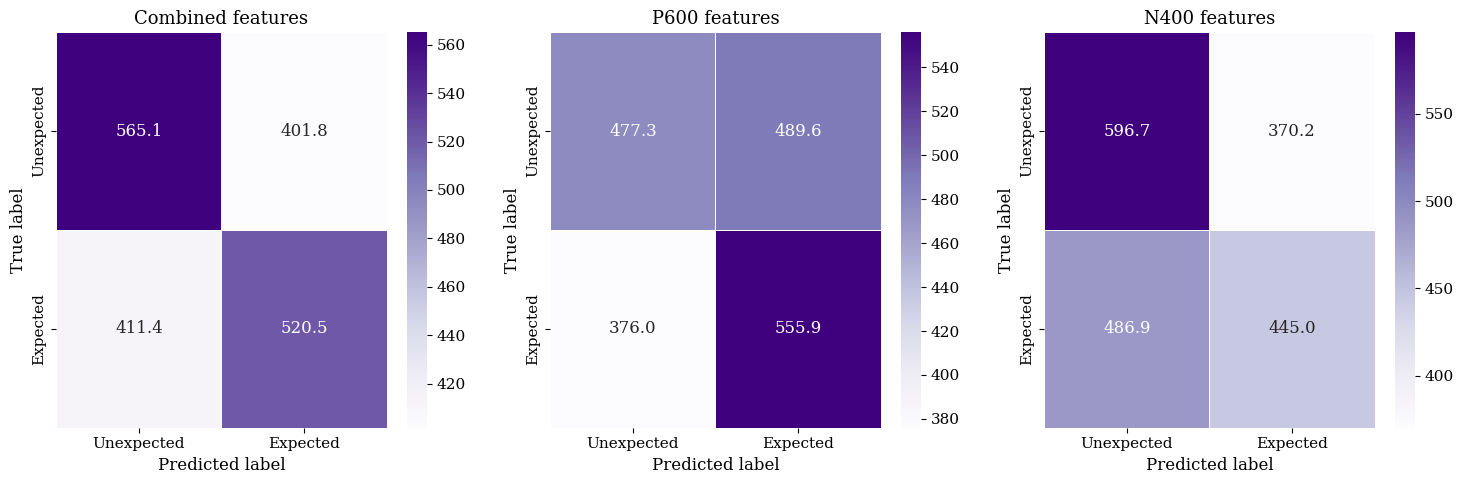

In [51]:
# keep same style as all figures
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

# default for pipeline consistency, same for all datasets
best_params_nb = {
    "model__var_smoothing": 1e-9
}

datasets = [(both_df, "Combined features"), (p600_df, "P600 features"), (n400_df, "N400 features")]

# three subplots, one for each dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.subplots_adjust(wspace=0.6)

for ax, (df, title) in zip(axes, datasets):

    # store confusion matrices across seeds
    all_confusion_nb = []

    for seed in range(10):
        X_train, X_test, y_train, y_test, _, _, _ = split(df, seed)
        _, results = evaluate_nb(X_train, X_test, y_train, y_test, best_params_nb, seed)
        all_confusion_nb.append(results["confusion_matrix"])

    # average confusion matrix across seeds
    mean_confusion = np.mean(all_confusion_nb, axis=0)

    sns.heatmap(
        mean_confusion,
        annot=True,
        fmt=".1f",          # one decimal since these are averaged counts
        cmap="Purples",
        xticklabels=["Unexpected", "Expected"],
        yticklabels=["Unexpected", "Expected"],
        linewidths=0.5,
        ax=ax,
        annot_kws={"size": 12}
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

# save
plt.tight_layout()
plt.savefig("confusion_matrix_nb_all.pdf", bbox_inches="tight")
plt.show()